In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from statsmodels.distributions.empirical_distribution import ECDF


## Walmart EDA

In [64]:

wmt = pd.read_csv('data/walmart_historico.csv', index_col=0, parse_dates=True)
retornos_diarios = pd.read_csv('data/retornos_diarios.csv', index_col=0, parse_dates=True)['WMT'].dropna()
retornos_semanais = pd.read_csv('data/retornos_semanais.csv', index_col=0, parse_dates=True)['WMT'].dropna()
retornos_mensais = pd.read_csv('data/retornos_mensais.csv', index_col=0, parse_dates=True)['WMT'].dropna()
precos = pd.read_csv('data/precos_limpos.csv', index_col=0, parse_dates=True)

display(retornos_diarios.head())


Date
2010-01-05   -0.010007
2010-01-06   -0.002238
2010-01-07    0.000560
2010-01-08   -0.005050
2010-01-11    0.016367
Name: WMT, dtype: float64

## Technical indicators: smoothing the price path

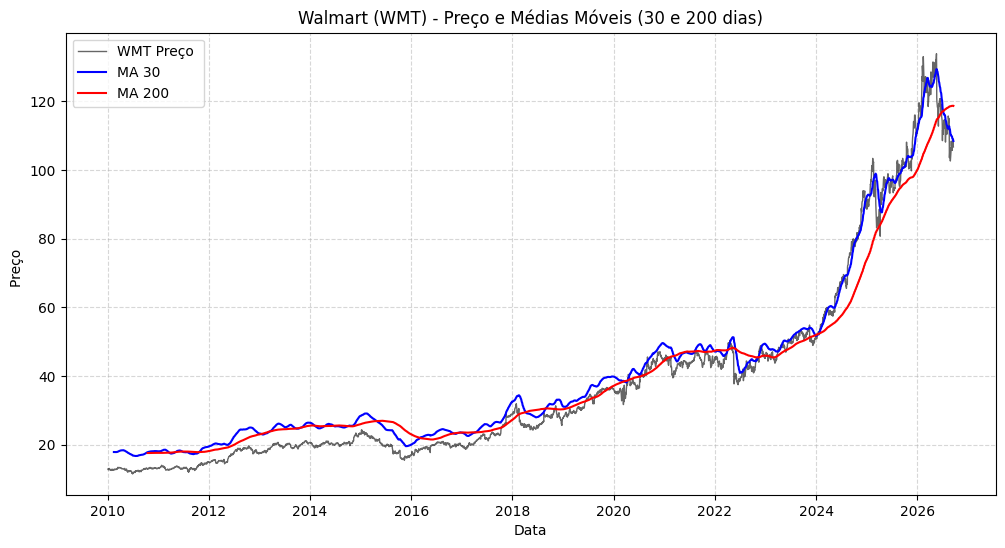

In [ ]:
#Calcular as Médias Móveis Simples (SMA) com base no 'Adj Close'
wmt['MA_30'] = wmt['Close'].rolling(window=30).mean()
wmt['MA_200'] = wmt['Close'].rolling(window=200).mean()


plt.figure(figsize=(12, 6))

# Linha do Preço Ajustado
plt.plot(wmt.index, wmt['Adj Close'], label='WMT Preço ', color='black', alpha=0.6, linewidth=1)

# Médias móveis
plt.plot(wmt.index, wmt['MA_30'], label='MA 30 ', color='blue', linewidth=1.5)
plt.plot(wmt.index, wmt['MA_200'], label='MA 200 ', color='red', linewidth=1.5)

# Configurações do gráfico
plt.title('Walmart (WMT) - Preço e Médias Móveis (30 e 200 dias)')
plt.xlabel('Data')
plt.ylabel('Preço  ')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

##  Walmart log returns

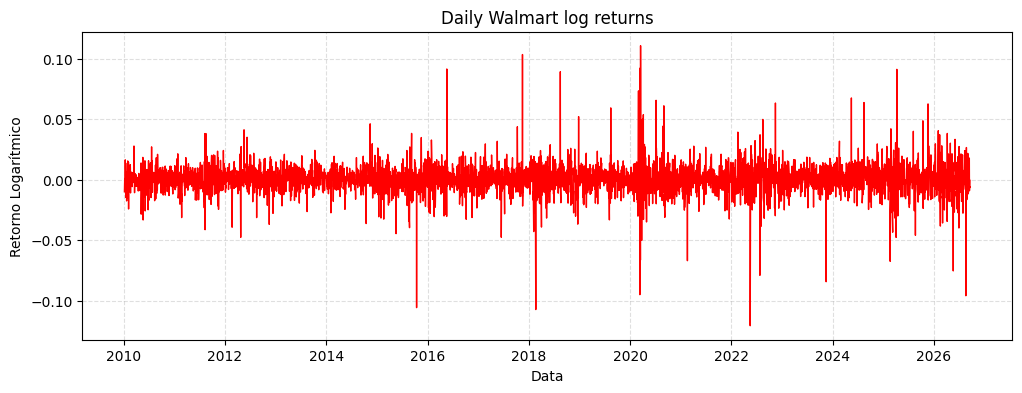

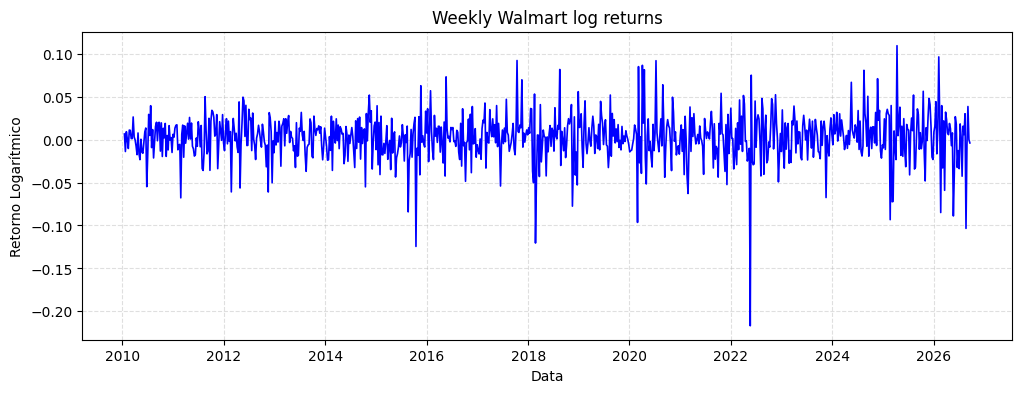

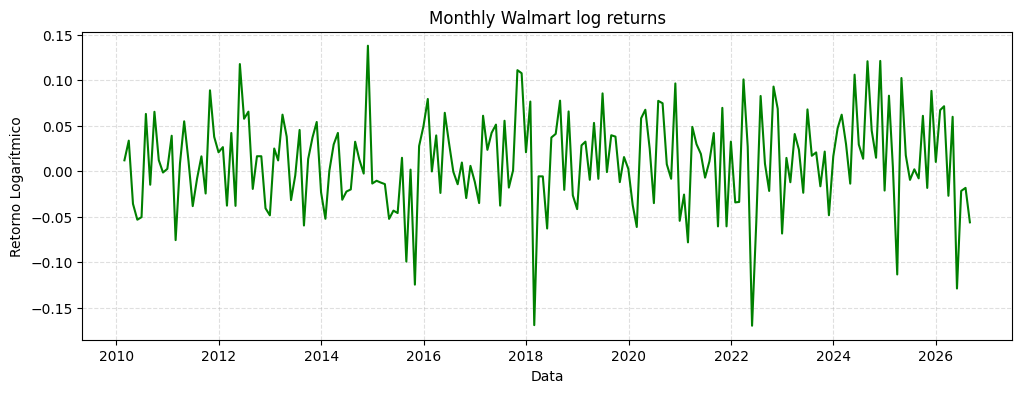

In [66]:


# --- Diário 
plt.figure(figsize=(12, 4))
plt.plot(retornos_diarios.index, retornos_diarios, color='red', linewidth=1)
plt.title('Daily Walmart log returns')
plt.xlabel('Data')
plt.ylabel('Retorno Logarítmico')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

# --- Semanal ---
plt.figure(figsize=(12, 4))
plt.plot(retornos_semanais.index, retornos_semanais, color='blue', linewidth=1.2)
plt.title('Weekly Walmart log returns')
plt.xlabel('Data')
plt.ylabel('Retorno Logarítmico')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

# --- Mensal ---
plt.figure(figsize=(12, 4))
plt.plot(retornos_mensais.index, retornos_mensais, color='green', linewidth=1.5)
plt.title('Monthly Walmart log returns')
plt.xlabel('Data')
plt.ylabel('Retorno Logarítmico')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

## Normalised price

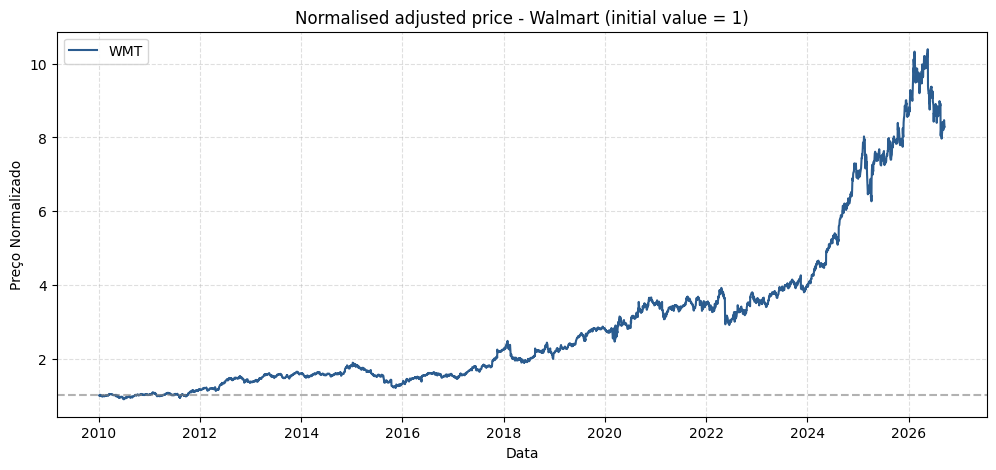

In [ ]:
wmt_preco = precos['WMT']

# Normalizar o preço dividindo pelo valor do primeiro dia 
wmt_normalizado = wmt_preco / wmt_preco.iloc[0]


plt.figure(figsize=(12, 5))
plt.plot(wmt_normalizado.index, wmt_normalizado, color='#2B5C8F', linewidth=1.5, label='WMT')

# Configurações 
plt.title('Normalised adjusted price - Walmart (initial value = 1)')
plt.xlabel('Data')
plt.ylabel('Preço Normalizado')
plt.axhline(y=1.0, color='gray', linestyle='--', alpha=0.6)  # Linha de referência 
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

## Annualised realised performance

In [ ]:
#Selecionar o preço ajustado da Walmart e calcular os retornos simples diários
retornos_simples = wmt_preco.pct_change().dropna()

# Parâmetros de anualização
scale = 252  # Dias úteis no ano
rf = 0.0     # (zero risk-free rate)

# Cálculos das métricas anualizadas 
# Retorno Composto Anualizado (CAGR)
retorno_anualizado = (1 + retornos_simples).prod() ** (scale / len(retornos_simples)) - 1

# Desvio Padrão Anualizado (Volatilidade)
volatilidade_anualizada = retornos_simples.std() * np.sqrt(scale)

# Índice de Sharpe Anualizado
sharpe_anualizado = (retorno_anualizado - rf) / volatilidade_anualizada

# tabela  
tabela_perf = pd.DataFrame({
    'Annualized Return': [retorno_anualizado],
    'Annualized Std Dev': [volatilidade_anualizada],
    'Annualized Sharpe (Rf=0%)': [sharpe_anualizado]
}, index=['WMT'])

# casas decimais
print("Annualised performance from simple returns; zero risk-free rate")
display(tabela_perf.round(4))

Annualised performance from simple returns; zero risk-free rate


,Annualized Return,Annualized Std Dev,Annualized Sharpe (Rf=0%)
WMT,0.1352,0.1999,0.6765


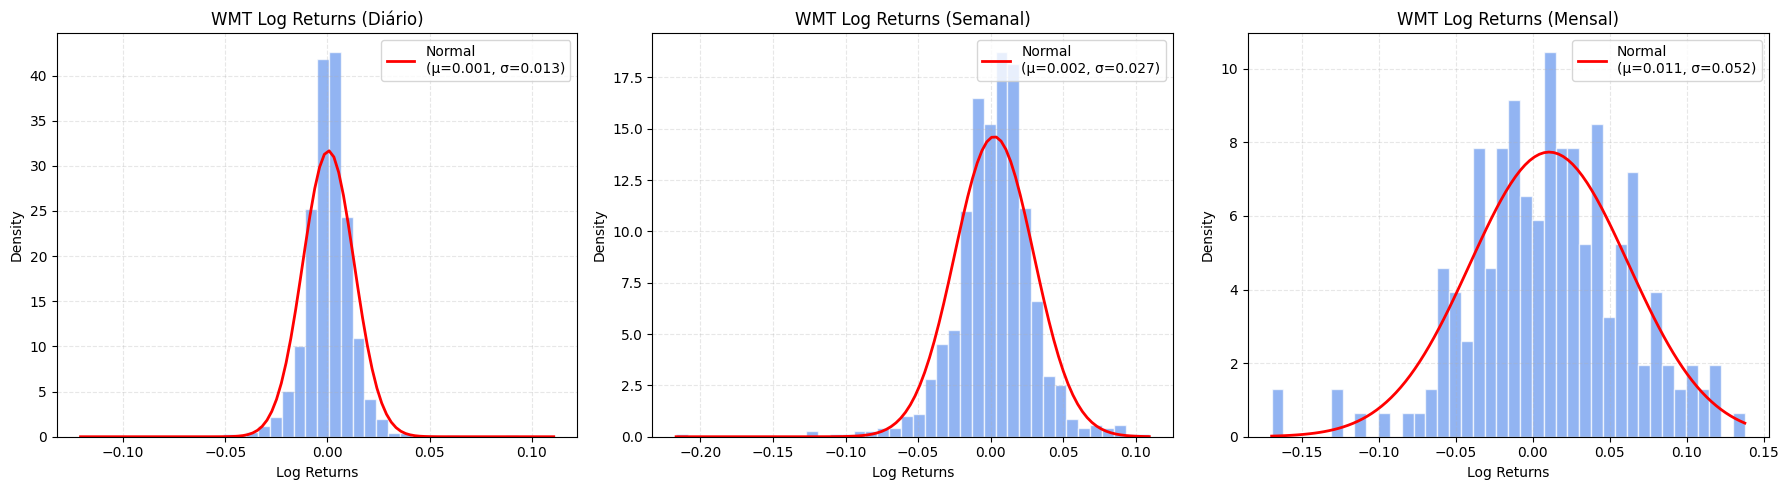

In [ ]:
# Configurar a figura com 3 subplots (1 linha, 3 colunas)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

frequencias = [('Diário', retornos_diarios, axes[0]), 
               ('Semanal', retornos_semanais, axes[1]), 
               ('Mensal', retornos_mensais, axes[2])]

for titulo, dados, ax in frequencias:
    # Histograma
    ax.hist(dados, bins=40, density=True, color='cornflowerblue', edgecolor='white', alpha=0.7)
    
    # Ajuste da Distribuição Normal (add.normal)
    mu, std = norm.fit(dados)
    x = np.linspace(dados.min(), dados.max(), 100)
    p = norm.pdf(x, mu, std)
    
    # Desenhar a Curva Normal
    ax.plot(x, p, 'r-', linewidth=2, label=f'Normal\n(μ={mu:.3f}, σ={std:.3f})')
    
    # Detalhes visuais
    ax.set_title(f'WMT Log Returns ({titulo})')
    ax.set_xlabel('Log Returns')
    ax.set_ylabel('Density')
    ax.legend(loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

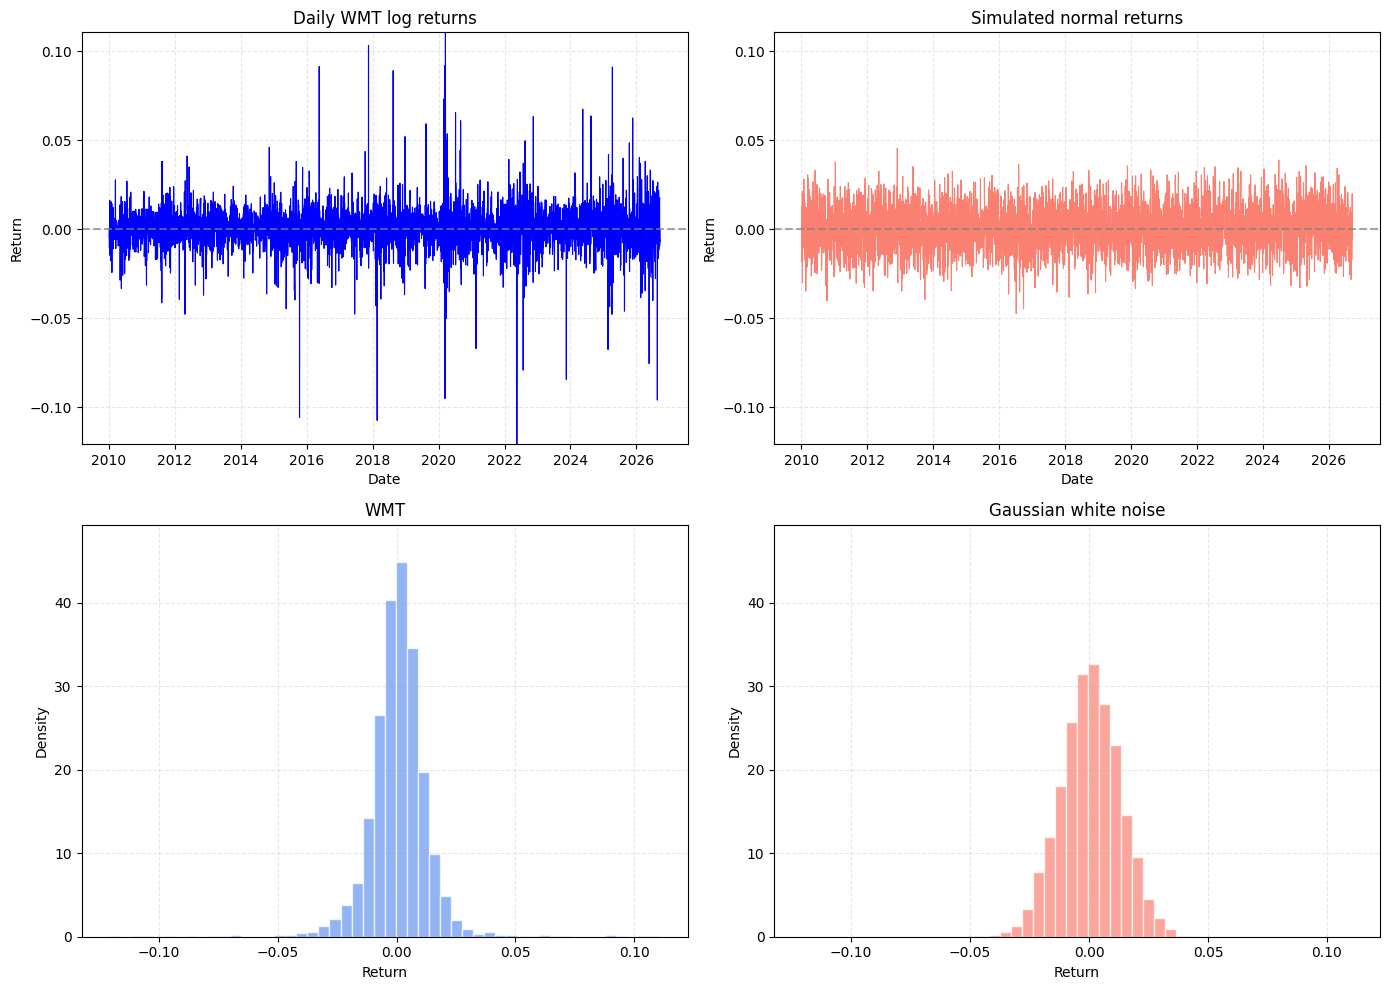

In [ ]:
#(equivalente ao set.seed(123) em R)
np.random.seed(123)

# Reutilizar os retornos diários que já tens
wmt_ret = retornos_diarios
# Gerar o Ruído Branco Gaussiano com a mesma média, desvio padrão e tamanho da WMT
mu = wmt_ret.mean()
std = wmt_ret.std()
gwn_daily = pd.Series(np.random.normal(loc=mu, scale=std, size=len(wmt_ret)), index=wmt_ret.index)

# Definir limites comuns para eixos (para permitir comparação direta exata)
lim_y_series = (min(wmt_ret.min(), gwn_daily.min()), max(wmt_ret.max(), gwn_daily.max()))

# -------------------------------------------------------------------
# Criar a grelha 2x2 de gráficos (mfrow = c(2, 2))
# -------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Gráfico 1: Séries Temporais Reais (WMT) ---
axes[0, 0].plot(wmt_ret.index, wmt_ret, color='blue', linewidth=0.8)
axes[0, 0].axhline(0, color='grey', linestyle='--', alpha=0.7)
axes[0, 0].set_ylim(lim_y_series)
axes[0, 0].set_title('Daily WMT log returns')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Return')
axes[0, 0].grid(True, linestyle='--', alpha=0.3)

# --- Gráfico 2: Séries Temporais Simuladas (Gaussian White Noise) ---
axes[0, 1].plot(gwn_daily.index, gwn_daily, color='salmon', linewidth=0.8)
axes[0, 1].axhline(0, color='grey', linestyle='--', alpha=0.7)
axes[0, 1].set_ylim(lim_y_series)
axes[0, 1].set_title('Simulated normal returns')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Return')
axes[0, 1].grid(True, linestyle='--', alpha=0.3)

# --- Criar bins padronizados para ambos os histogramas ---
bins = np.linspace(lim_y_series[0], lim_y_series[1], 51)

# --- Gráfico 3: Histograma Real (WMT) ---
count_wmt, _, _ = axes[1, 0].hist(wmt_ret, bins=bins, density=True, color='cornflowerblue', edgecolor='white', alpha=0.7)
axes[1, 0].set_title('WMT')
axes[1, 0].set_xlabel('Return')
axes[1, 0].set_ylabel('Density')
axes[1, 0].grid(True, linestyle='--', alpha=0.3)

# --- Gráfico 4: Histograma Simulado (Gaussian White Noise) ---
count_gwn, _, _ = axes[1, 1].hist(gwn_daily, bins=bins, density=True, color='salmon', edgecolor='white', alpha=0.7)
axes[1, 1].set_title('Gaussian white noise')
axes[1, 1].set_xlabel('Return')
axes[1, 1].set_ylabel('Density')
axes[1, 1].grid(True, linestyle='--', alpha=0.3)

# Igualar a escala do eixo Y nos dois histogramas para comparação visual 
max_y_hist = max(count_wmt.max(), count_gwn.max()) * 1.1
axes[1, 0].set_ylim(0, max_y_hist)
axes[1, 1].set_ylim(0, max_y_hist)

plt.tight_layout()
plt.show()

## Fitted normal density on the actual histogram

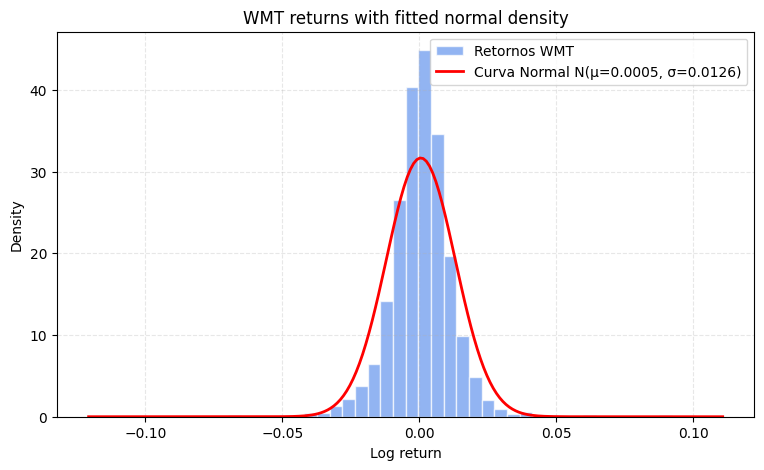

In [ ]:
#Criar o histograma 
plt.figure(figsize=(9, 5))

count, bins, _ = plt.hist(
    wmt_ret, 
    bins=50, 
    density=True, 
    color='cornflowerblue', 
    edgecolor='white', 
    alpha=0.7, 
    label='Retornos WMT'
)

# Sobrepor a curva da Distribuição Normal ajustada 
mu = wmt_ret.mean()
std = wmt_ret.std()

x = np.linspace(wmt_ret.min(), wmt_ret.max(), 200)
p = norm.pdf(x, mu, std)  # dnorm em R é o pdf (probability density function) em scipy

plt.plot(x, p, color='red', linewidth=2, label=f'Curva Normal N(μ={mu:.4f}, σ={std:.4f})')

# Configurações visuais equivalentes
plt.title("WMT returns with fitted normal density")
plt.xlabel("Log return")
plt.ylabel("Density")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()

## Empirical cumulative distribution function

Empirical probability of a daily drop greater than 5%:


,Threshold,Empirical_probability
0,-0.051293,0.002856


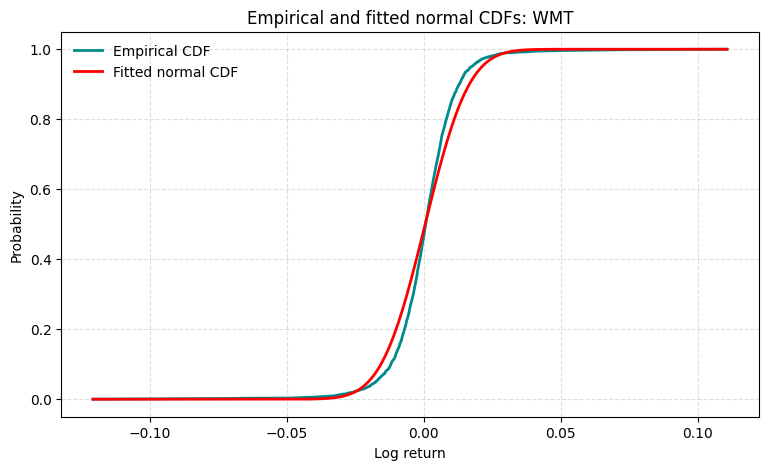

In [ ]:
# o limiar (queda de 5% -> log(0.95)) e calcular a probabilidade empírica
threshold = np.log(0.95)
f_hat = (wmt_ret <= threshold).mean()

# Criar e exibir a tabela (equivalente ao knitr::kable)
tabela_prob = pd.DataFrame({
    'Threshold': [threshold],
    'Empirical_probability': [f_hat]
})

print("Empirical probability of a daily drop greater than 5%:")
display(tabela_prob.round(6))

# Calcular a ECDF (Função Distribuição Acumulada Empírica)
ecdf = ECDF(wmt_ret)

# Desenhar o gráfico de CDFs (Empírica vs Normal Teórica)
plt.figure(figsize=(9, 5))

# ECDF real dos dados (linha verde)
x_ecdf = np.sort(wmt_ret)
plt.plot(x_ecdf, ecdf(x_ecdf), color='darkcyan', linewidth=2, label='Empirical CDF')

# CDF Normal teórica (linha vermelha)
mu, std = wmt_ret.mean(), wmt_ret.std()
x = np.linspace(wmt_ret.min(), wmt_ret.max(), 300)
plt.plot(x, norm.cdf(x, mu, std), color='red', linewidth=2, label='Fitted normal CDF')


plt.title("Empirical and fitted normal CDFs: WMT")
plt.xlabel("Log return")
plt.ylabel("Probability")
plt.legend(loc='upper left', frameon=False)
plt.grid(True, linestyle='--', alpha=0.4)

plt.show()